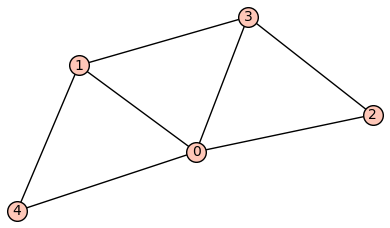

In [11]:
%run Packages.ipynb
%run Cycle_Mtx_functions.ipynb
%run Graph_Generators.ipynb
%run Metric_Repair_Algorithms.ipynb
import pandas as pd
import seaborn as sns

In [12]:
def random_weighted_graph_uniform(n, p, lower_weight = .01, upper_weight = 1): 
    # Does not take metrics into account, just a regular random graph
    g = graphs.RandomGNP(n,p)
    m = g.num_edges()
    weights = np.random.uniform(size=m)
    uw_edges = g.edges(sort = True)
    
    # Create weighted graph edge list 
    w_edges = [(uw_edges[i][0], uw_edges[i][1], weights[i]) for i in range(m)]
    
    return Graph(w_edges, weighted = True)

def random_weighted_graph_exponential(n, p): 
    # Does not take metrics into account, just a regular random graph
    g = graphs.RandomGNP(n,p)
    m = g.num_edges()
    weights = np.random.exponential(size=m)
    uw_edges = g.edges(sort = True)
    
    # Create weighted graph edge list 
    w_edges = [(uw_edges[i][0], uw_edges[i][1], weights[i]) for i in range(m)]
    
    return Graph(w_edges, weighted = True)

In [3]:
def csv_to_array(path):
    df = pd.read_csv(path,index_col=0)  
    return df.to_numpy()

In [136]:
def is_broken(K):
    A = K.weighted_adjacency_matrix()
    n = len(A[0])
    for i in range(n):
        for j in range(n):
            for k in range(j):
                if A[i,k] > A[i,j] + A[j,k]:
                    return 1
    return 0
    
def has_cycle(G):
    for u,v in G.edges(sort=True,labels=False):
        H =G.copy()
        H.delete_edge(u,v)
        if len(H.shortest_path(u,v)) > 0:
            return 1
    return 0


def experiment_demonstrate_threshold_prob(N = 40,AVG = 100, ps=100,std=False):
    delta = 1.9/ps
    P = [2 - i*delta for i in range(ps)]
    res = np.zeros((2,ps))
    res_std = np.zeros((2,ps))
    for j,q in enumerate(P):
        print(f"finished {(j/ps)*100}%")
        p = 1/np.power(N,q)
        samples_broken=np.zeros(AVG)
        samples_cycles=np.zeros(AVG)
        has_broken = 0
        has_a_cycle = 0
        for trial in range(AVG):
            G = random_weighted_graph_uniform(N,p)
            while G.size() == 0: # Make sure the graph has edges
                G = random_weighted_graph_uniform(N,p)
            bit = has_cycle(G)
            samples_cycles[trial]= bit
            has_a_cycle +=bit    

            bit = 0
            for CC in connected_components_subgraphs(G):
                bit = is_broken(complete(CC))
                if bit == 1:
                    samples_broken[trial] = bit
                    has_broken +=bit
                    break
        res[0,j] = has_broken/AVG ### Broken Cycles
        res[1,j] = has_a_cycle/AVG # how many induced cycles 
        res_std[0,j]=np.std(samples_broken)/np.sqrt(AVG)
        res_std[1,j]=np.std(samples_cycles)/np.sqrt(AVG)         
    if std:
        return res,res_std
    else:
        return res



### Experiment - how many edges we discard when running algorithms
def experiment_heuristics_on_G_and_KG(n1=50,n2=130,p = lambda x: np.power(x,-0.5),AVG = 80):
    """
    p would be a function of n, or a constant function. But we definitly expect it to be a function N -> (0,1)
    """
    N = range(n1,n2)
    res = np.zeros((11,len(N)))
    start_time = time.time()
    for i,n in enumerate(N):
        ### Keep track of progress
        if i % 10 == 0:
            print(f"Completed: {i/len(N)*100}% \n" + "Elapsed Time: " + str((time.time() - start_time)/60))
        ### Iterate over connected Components
        for j in range(AVG):
            B = False
            while B == False: # Make sure the graph is broken
                G = random_weighted_graph_uniform(n,p(n))
                DOMR_solns = list()
                for CC in connected_components_subgraphs(G):
                    DOMR = domr_alg(CC)
                    if len(DOMR) > 0:
                        B = True
                    DOMR_solns.append(len(DOMR))
                if B:
                    PIVOT_solns = list()
                    LHS_solns = list()
                    SPC_MR_solns = list()
                    SPC_IOMR_solns = list()
                    REDUCED_SPC_MR_solns = list() # running SPC on complete and discarding whatever's not needed
                    REDUCED_SPC_IOMR_solns = list()
                    
                    COM_PIVOT_solns = list()
                    COM_LHS_solns = list()
                    COM_SPC_MR_solns = list()
                    COM_SPC_IOMR_solns = list()
                    
                    REDUCED_SPC_MR_solns = list() # running SPC on complete and discarding whatever's not needed
                    REDUCED_SPC_IOMR_solns = list()
                    for CC in connected_components_subgraphs(G):
                        comCC = complete(CC)
                        PIVOT_solns.append(len(pivot_heuristic(CC)))
                        SPC_MR_solns.append(len(shortest_path_cover(CC)))
                        SPC_IOMR_solns.append(len(shortest_path_cover(CC,general=0)))

                        LHS_solns.append(len(left_edge_heuristic(CC)))
                        COM_PIVOT_solns.append(len(pivot_heuristic(comCC)))
                        COM_LHS_solns.append(len(left_edge_heuristic(comCC)))

                        # save the result for completion, need to reduce    
#                         complete_MR_SPC = shortest_path_cover(comCC) 
#                         complete_IOMR_SPC = shortest_path_cover(comCC,general=0)

#                         COM_SPC_MR_solns.append(len(complete_MR_SPC))
#                         COM_SPC_IOMR_solns.append(len(complete_IOMR_SPC))

#                         REDUCED_SPC_MR_solns.append(len(reduce_solution(complete_MR_SPC,CC)))
#                         REDUCED_SPC_IOMR_solns.append(len(reduce_solution(complete_IOMR_SPC,CC)))

                    res[0,i] += sum(DOMR_solns)/AVG
                    res[1,i] += sum(PIVOT_solns)/AVG
                    res[2,i] += sum(COM_PIVOT_solns)/AVG
                    res[3,i] += sum(LHS_solns)/AVG
                    res[4,i] += sum(COM_LHS_solns)/AVG
                    res[5,i] += sum(SPC_MR_solns)/AVG
#                     res[6,i] += sum(COM_SPC_MR_solns)/AVG
                    res[7,i] += sum(SPC_IOMR_solns)/AVG
#                     res[8,i] += sum(COM_SPC_IOMR_solns)/AVG
#                     res[9,i] += sum(REDUCED_SPC_MR_solns)/AVG
#                     res[10,i] += sum(REDUCED_SPC_IOMR_solns)/AVG

    return res

def experiment_algs_as_function_of_p(start=1-0.1, end=0.1,ps=100,AVG = 100,n=70):
    delta = (start-end)/ps
    P = [end + delta*i for i in range(ps)]
    res = res = np.zeros((11,len(P)))
    start_time = time.time()

    for i,p in enumerate(P):
        if i % 10 == 0:
            print(f"Completed: {i/len(P)*100}% \n" + "Elapsed Time: " + str((time.time() - start_time)/60))
        for j in range(AVG):
            B = False
            while B == False: # Make sure the graph is broken
                G = random_weighted_graph_uniform(n,p)
                DOMR_solns = list()
                for CC in connected_components_subgraphs(G):
                    DOMR = domr_alg(CC)
                    if len(DOMR) > 0:
                        B = True
                    DOMR_solns.append(len(DOMR))
                if B:
                    PIVOT_solns = list()
                    LHS_solns = list()
                    SPC_MR_solns = list()
                    SPC_IOMR_solns = list()
                    REDUCED_SPC_MR_solns = list() # running SPC on complete and discarding whatever's not needed
                    REDUCED_SPC_IOMR_solns = list()
                    
                    COM_PIVOT_solns = list()
                    COM_LHS_solns = list()
                    COM_SPC_MR_solns = list()
                    COM_SPC_IOMR_solns = list()
                    
                    REDUCED_SPC_MR_solns = list() # running SPC on complete and discarding whatever's not needed
                    REDUCED_SPC_IOMR_solns = list()
                    
                    for CC in connected_components_subgraphs(G):
                        comCC = complete(CC)
                        PIVOT_solns.append(len(pivot_heuristic(CC)))
                        SPC_MR_solns.append(len(shortest_path_cover(CC)))
                        SPC_IOMR_solns.append(len(shortest_path_cover(CC,general=0)))

                        LHS_solns.append(len(left_edge_heuristic(CC)))
                        COM_PIVOT_solns.append(len(pivot_heuristic(comCC)))
                        COM_LHS_solns.append(len(left_edge_heuristic(comCC)))

                        # save the result for completion, need to reduce    
#                         complete_MR_SPC = shortest_path_cover(comCC) 
#                         complete_IOMR_SPC = shortest_path_cover(comCC,general=0)

#                         COM_SPC_MR_solns.append(len(complete_MR_SPC))
#                         COM_SPC_IOMR_solns.append(len(complete_IOMR_SPC))

#                         REDUCED_SPC_MR_solns.append(len(reduce_solution(complete_MR_SPC,CC)))
#                         REDUCED_SPC_IOMR_solns.append(len(reduce_solution(complete_IOMR_SPC,CC)))

                    res[0,i] += sum(DOMR_solns)/AVG
                    res[1,i] += sum(PIVOT_solns)/AVG
                    res[2,i] += sum(COM_PIVOT_solns)/AVG
                    res[3,i] += sum(LHS_solns)/AVG
                    res[4,i] += sum(COM_LHS_solns)/AVG
                    res[5,i] += sum(SPC_MR_solns)/AVG
#                     res[6,i] += sum(COM_SPC_MR_solns)/AVG
                    res[7,i] += sum(SPC_IOMR_solns)/AVG
#                     res[8,i] += sum(COM_SPC_IOMR_solns)/AVG
#                     res[9,i] += sum(REDUCED_SPC_MR_solns)/AVG
#                     res[10,i] += sum(REDUCED_SPC_IOMR_solns)/AVG
    return res


In [52]:
n1 = 20
n2 = 50
AVG =30
ps = 20

In [138]:
print("###############################################")
print("Starting Experiments")
print("###############################################\n")
print("Starting: Threshold phenomena")
print("####################\n")

ar_df,ar_dfstd = experiment_demonstrate_threshold_prob(AVG=AVG,ps=ps,std=True)
df,dfstd = pd.DataFrame(ar_df), pd.DataFrame(ar_dfstd)
df.to_csv("unifdem_threshold_prob.csv")
dfstd.to_csv("unif_dem_threshold_prob_std.csv")



###############################################
Starting Experiments
###############################################

Starting: Threshold phenomena
####################

finished 0%
finished 5%
finished 10%
finished 15%
finished 20%
finished 25%
finished 30%
finished 35%
finished 40%
finished 45%
finished 50%
finished 55%
finished 60%
finished 65%
finished 70%
finished 75%
finished 80%
finished 85%
finished 90%
finished 95%


In [137]:
# print("\n###############################################")
# print("Starting: Algorithms\n")
# print("For Gamma(n,p)")
# print("p=0.8")
# df = pd.DataFrame(experiment_heuristics_on_G_and_KG(n1=n1,n2=n2,AVG=AVG,p=lambda x: .8))
# df.to_csv("unif_alg_p08.csv")

print("####################\n")
print("p=0.2")
df = pd.DataFrame(experiment_heuristics_on_G_and_KG(n1=n1,n2=n2,AVG=AVG,p= lambda x: .3))
df.to_csv("unif_alg_p02.csv")


print("####################\n")
print("p=1/sqrt(n) - to make sure we have lots of broken cycles") ## To make sure it's connected
df = pd.DataFrame(experiment_heuristics_on_G_and_KG(n1=n1,n2=n2,AVG=AVG,p= lambda x: (1)/np.power(x,.5)))
df.to_csv("unif_alg_p_sqrt(n).csv")

print("####################\n")
print("p=2/n - giant CC")
df = pd.DataFrame(experiment_heuristics_on_G_and_KG(n1=n1,n2=n2,AVG=AVG,p= lambda x: 2/x))
df.to_csv("unif_alg_p1overn.csv")

####################

p=0.2
Completed: 0.0% 
Elapsed Time: 4.967053731282552e-07
Completed: 33.33333333333333% 
Elapsed Time: 0.24321544965108235
Completed: 66.66666666666666% 
Elapsed Time: 0.8734364986419678
####################

p=1/sqrt(n) - to make sure we have lots of broken cycles
Completed: 0.0% 
Elapsed Time: 9.338061014811198e-07
Completed: 33.33333333333333% 
Elapsed Time: 0.2173885663350423
Completed: 66.66666666666666% 
Elapsed Time: 0.7723388989766439
####################

p=2/n - giant CC
Completed: 0.0% 
Elapsed Time: 1.1165936787923178e-06
Completed: 33.33333333333333% 
Elapsed Time: 0.13377044598261514
Completed: 66.66666666666666% 
Elapsed Time: 0.4613430460294088


In [ ]:
print("\n###############################################")
print("Starting: Algorithms as function of p\n")
df = pd.DataFrame(experiment_algs_as_function_of_p(ps=ps,AVG=AVG))
df.to_csv("unif_algos_as_fn_p.csv")

In [3]:
direct = "plots_paper/"
results_direct = "res_finalle/"

# Threshold phenomena

In [4]:
#Load Everything
# gamma_threshold = csv_to_array(results_direct+"dem_threshold.csv")
threshold_prob = csv_to_array(results_direct+"dem_threshold_prob.csv")
threshold_prob_err = csv_to_array(results_direct + "dem_threshold_prob_std.csv")
# knunif_threshold = csv_to_array(results_direct+"dem_threshold_uniform.csv")
# knunif_threshold_prob=csv_to_array(results_direct+"dem_threshold_uniform_prob.csv")

# thresh = [gamma_threshold, knunif_threshold]
# thresh_prob = [gamma_threshold_prob, knunif_threshold_prob]
# thresh_prob = [gamma_threshold_prob]

In [5]:
# Set up range
ps = len(threshold_prob[0])
powers = [2 - (1.9/ps)*i for i in range(ps)]

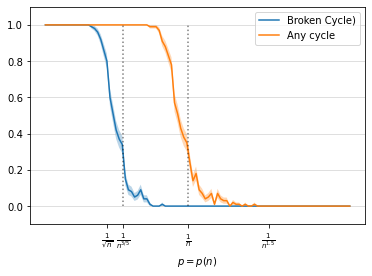

In [104]:
# Plot threshold for Gamma

#Don't love these plots, don't show much
# plt.plot(powers,gamma_threshold[0], label="# Broken Cycles ($\Gamma(n,p)$)")
# plt.plot(powers,gamma_threshold[1],label="# Induced Cycles ($\Gamma(n,p)$)")
# sns.set_style("whitegrid", {'axes.grid' : False})
# sns.set_style("darkgrid")
# sns.color_palette("Paired")

fig, ax = plt.subplots()
ax.plot(powers,threshold_prob[0],label = "Broken Cycle)")
ax.fill_between(powers,threshold_prob[0]+threshold_prob_err[0],threshold_prob[0]-threshold_prob_err[0],alpha=.3)
ax.fill_between(powers,threshold_prob[1]+threshold_prob_err[1],threshold_prob[1]-threshold_prob_err[1],alpha=.3)
ax.plot(powers,threshold_prob[1], label = "Any cycle")
ax.vlines([3/5,1],0,1,color='0',linestyles='dotted',alpha=.5)
# ax.legend()


ax.yaxis.label.set(rotation='horizontal', ha='right');
# ax.yaxis.label.set(text="Probability of\n appearance")
ax.xaxis.label.set(text = "$p=p(n)$")
ax.title.set_family('serif')
ax.grid(axis='y',alpha=.5)
ax.legend()
ax.set_ylim([-.1,1.1])
ax.set_xticks([.5,3/5,1,1.5], labels=["$\\frac{1}{\\sqrt{n}}$","$\\frac{1}{n^{3/5}}$","$\\frac{1}{n}$","$\\frac{1}{n^{1.5}}$"])

fig.savefig(direct + "threshold_probability.svg")
fig.show()

# plt.errorbar(powers,threshold_prob[0],yerr=threshold_prob_err[0], label = "Prob of Broken Cycle($\Gamma(n,p)$)")
# plt.errorbar(powers,threshold_prob[1],yerr=threshold_prob_err[1], label = "Prob of any Cycle($\Gamma(n,p)$)")
# # plt.scatter(powers,threshold_prob[0],marker='.')
# # plt.scatter(powers,threshold_prob[1],marker='.')
# # plt.errorbar(powers,threshold_prob_err[0])
# # plt.plot(powers,threshold_prob[1],label = ")
# # plt.errorbar(powers,threshold_prob_err[0])
# plt.title("Probability of a (broken) cycle in $\Gamma(n,p)$ as a function of $p(n)$")
# plt.xlabel("Power of $1/n$")
# plt.xticks([.5,1,1.5], labels=["$\\frac{1}{\\sqrt{n}}$","$\\frac{1}{n}$","$\\frac{1}{n^{1.5}}$"])
# plt.ylabel("Probability of appearance")
# plt.legend()
# plt.show()
# plt.savefig(direct + "threshold_probability.png")

# Performance of Algorithms

## Different Target Metrics
### Algorithms as a funciton of $n$
We have three different ranges we wish to plot as a funciton of n:
1. $||soln||/\mathbb{E}(|E|)$
2. $||soln||/\mathbb{E}(|\mathcal{C}|)$
3. Num edges discarded

### Algorithms as a function of $p$
We set $n=70$ and change $p$, as we measure the preformance of the algorithms

## Functions needed for computations
We save the functions for $p(n)$ needed to preform computatins, and also functions to compute expectations etc.

In [27]:
# funcions for p
const02 = lambda x: .2
const08 = lambda x: .8
over_sqrt = lambda x : 1/np.sqrt(x)
over_n = lambda x : 2/x


# function for "relative to what we measure success"
expected_num_edges = lambda x,p : (x * (x-1)/2)*p(x) #Computes the expected number of edges
def expected_num_broken_cycles(x,p):
    if p(x) == p(x+10):
        q = x*p(x)*p(x)
        return (q * np.power(q,x) - q*q)/(q-1)
    elif p(x) == over_sqrt(x):
        return x*np.sqrt(x)
    else:
        return 1

# Number of vertice range for function of n
Nrange = range(50,130)

# Values of p for function of p
start=1-0.1
end=0.1
ps=100
delta = (start-end)/ps
Prange = [end + delta*i for i in range(ps)]
# print(expected_num_broken_cycles(100,over_sqrt))

### Dictionaries of Names for plots and headers

In [125]:

## Names for headers
experiment_dict = {0: "$p=0.2$",
                  1: "$p=0.8$",
                  2: "$p=1/\sqrt{n}$",
                  3: "$p=2/n$"}

relative_dict = {0: "$\\frac{|sol|}{\mathbf{E}(|E|)}$",
                1: "$\\frac{|sol|}{\mathbf{E}(|\mathscr{C}|)}$",
                2: "|sol|"}

algo_dict = {0 : 'DOMR',
            1 : 'PIVOT',
            2 : 'Pivot (Complete)',
            3: 'LHS',
            4: 'LHS (Complete)',
            5: 'L+1 Appx (general)',
            6: 'L+1 Appx (general, Complete)',
            7: 'L Appx (IOMR)',
            8: 'L Appx (IOMR, Complete)',
            9: 'L+1 Appx Reduced',
            10: 'L Appx (IOMR) Reduced '}


colors = sns.color_palette()

algo_color_dict = {0: colors[4],
                  1: colors[0],
                  2: colors[0],
                  3: colors[0],
                  4: colors[0],
                  5: colors[1],
                  6: colors[1],
                  7: colors[1],
                  8: colors[1],
                  9: colors[2],
                  10: colors[3]}
## Names for files
relative_names = {0: "ExpEdges",
                 1: "ExpCycles",
                 2: ""}
experiment_names = {0: "p=0.2",
                  1: "p=0.8",
                  2: "p=1_over_sqrt{n}",
                  3: "p=2over_n"}



### Total Collections
all values of p, all files, all relative functions, all algorithms

In [128]:
## Load all files
algs_08 = csv_to_array(results_direct+"alg_p08.csv")
algs_02 = csv_to_array(results_direct+"alg_p03.csv")
# algs_n = csv_to_array(results_direct+"alg_p2overn.csv")
algs_sqrt = csv_to_array(results_direct+"alg_p_sqrt(n).csv")

# Load Preformance as function of $p$
pref_as_fn_p = csv_to_array(results_direct+"algos_as_fn_p.csv")

## Lists of all things needed
ALL_P = [const02, const08, over_sqrt, over_n]
ALL_RES = [algs_02, algs_08, algs_sqrt]
# ALL_RES = [algs_03, algs_07, algs_sqrt, algs_n]
ALL_RELATIVE = [expected_num_edges, expected_num_broken_cycles, lambda x,y : 1]

ALL_ALGS_WITH_REMOVAL = set([1,3,9,10])


ALL_GENERAL_GRAPHS=set([0,1,3,5,7,9,10]) ## All results for general graphs
ALL_IOMR = set([3,4,7,8,10]) ## All IOMR algiorithms
ALL_MR = set([1,2,5,6,9]) ## All GMR algorithms
ALL_COMPLETE = set([0,2,4,6,8]) ## All results for complete graphs

ALL_BEFORE_11_ALGS = set(range(9)) ## To intersect for results before round 3

## Dictionary to send index of algorithm after reduction to its counterpart  - 
## that is, before reduction but after completion, like Pivot(complete) to Pivot

reduction_dict={1:2, #Pivot
               3:4,
               9:6,
               10:7} #L+1 appxn


### Plotting Functions

In [117]:

def plot_soln_over_rel(res,p = lambda x: .3,which_algs = ALL_GENERAL_GRAPHS,N=Nrange,
                       title = "Default",rel = lambda x,y: 1,
                      xlabel="", ylabel="", save=False):
    """p is a function of n, default to be constant .7
    rel is the denomenator in the range of the function """
    denom = np.array([rel(n,p) for n in N])
    fig, ax = plt.subplots()
    for i in which_algs:
        if i in ALL_COMPLETE:
            ax.plot(N,res[i]/denom,label=algo_dict[i],color=algo_color_dict[i], linestyle='dotted')
        else:
            ax.plot(N,res[i]/denom,label=algo_dict[i],color=algo_color_dict[i])
            
    ax.grid(axis='y',alpha=.5)
#     if p(100) == .8 and rel(10,p) == expected_num_broken_cycles(10,p):
#         ax.set_yscale('log')
#     ax.yaxis.label.set(rotation='horizontal', ha='right',x=-5);
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.title.set_text(title)
#     fig.show()
    if save:
        fig.savefig(direct + save) 
    else:
        fig.show()
        
def plot_num_edges_removed(res,N = Nrange, which_algs = ALL_GENERAL_GRAPHS,relative = False,
                           title = "Default", xlabel="", ylabel="", save=False):
    fig, ax = plt.subplots()
    if not relative:
        for i in which_algs & ALL_ALGS_WITH_REMOVAL:
#             if i > 3:
#                 break
            if i in ALL_COMPLETE:
                ax.plot(N, (res[i+1]-res[i]),label=algo_dict[i],color=algo_color_dict[i], linestyle='dotted')
            else:
                ax.plot(N, (res[i+1]-res[i]),label=algo_dict[i],color=algo_color_dict[i],)
    else:
        for i in which_algs& ALL_ALGS_WITH_REMOVAL:
#             if i > 3:
#                 break
            if i in ALL_COMPLETE:
                ax.plot(N, (res[reduction_dict[i]]-res[i])/res[reduction_dict[i]],label=algo_dict[i],
                        color=algo_color_dict[i],linestyle='dotted')
            else:
                ax.plot(N, (res[reduction_dict[i]]-res[i])/res[reduction_dict[i]],label=algo_dict[i],
                        color=algo_color_dict[i])
    ax.grid(axis='y',alpha=.5)
#     ax.yaxis.label.set(rotation='horizontal', ha='right');
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.title.set_text(title)
    if save:
        fig.savefig(direct + save) 
    else:
        fig.show()

def algs_as_fn_p(res,P = Prange, which_algs = ALL_GENERAL_GRAPHS,rel = lambda x,y: 1,DOMR=False,
                           title = "Default", xlabel="", ylabel="", save=False):
    fig, ax = plt.subplots()

    if DOMR:
        ax.plot(P,res[0],label=algo_dict[0])
    denom = np.array([rel(70,lambda x:p) for p in Prange])
    for i in which_algs:
        if i in ALL_COMPLETE:
            ax.plot(P,res[i]/denom,label=algo_dict[i],color=algo_color_dict[i],linestyle='dotted')
        else:
            ax.plot(P,res[i]/denom,label=algo_dict[i],color=algo_color_dict[i])
    ax.grid(axis='y',alpha=.5)

#     ax.yaxis.label.set(rotation='horizontal', ha='left');
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.title.set_text(title)
    if save:
        fig.savefig(direct + save) 
    else:
        fig.show()

## General Metric Repair

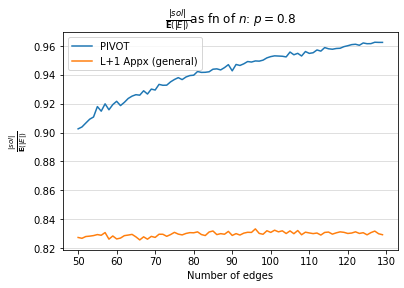

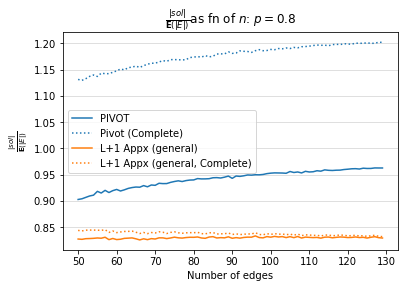

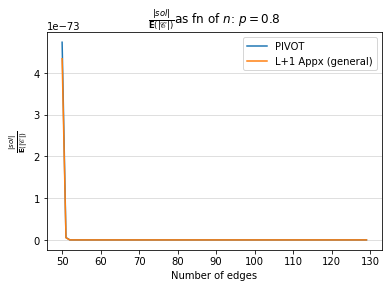

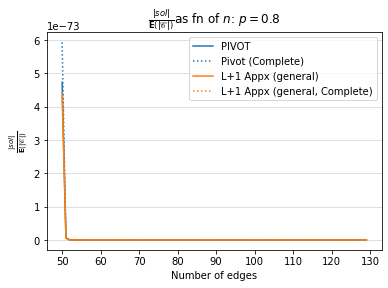

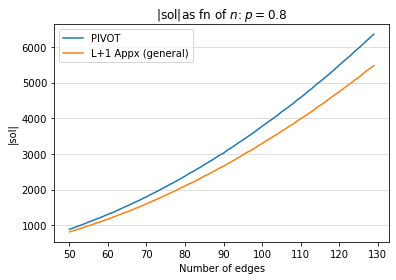

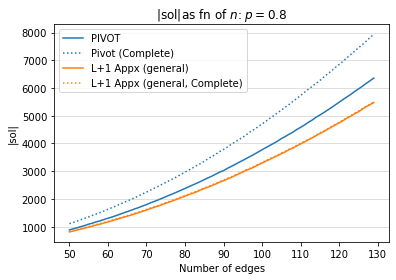

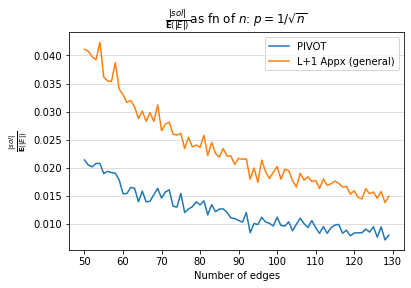

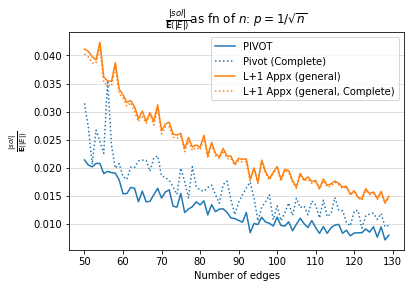

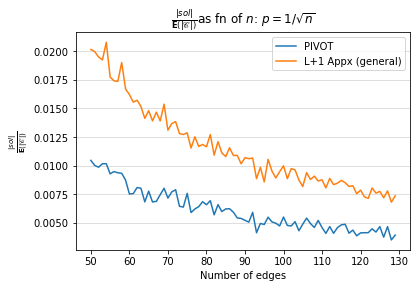

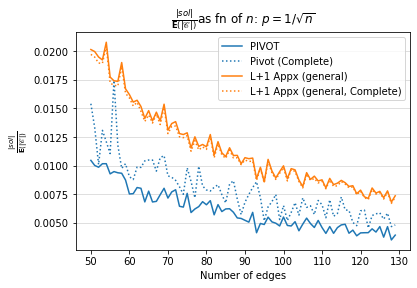

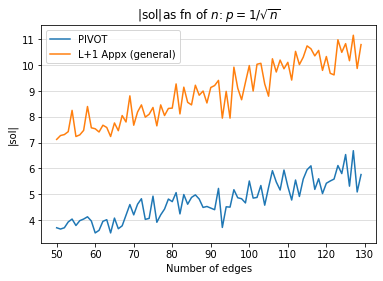

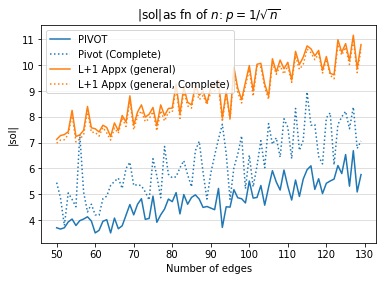

In [129]:
#Plot all relative results
for i in range(3):
    if i == 0:
        continue
    p = ALL_P[i]
    res = ALL_RES[i]
    title = "as fn of $n$: " + experiment_dict[i]
    for j,rel in enumerate(ALL_RELATIVE):
        title = relative_dict[j] + "as fn of $n$: " + experiment_dict[i]
        savename = "GMR/" + "sol_size_over" + relative_names[j] + experiment_names[i] + "GMR_general" +".png"
#         savename=False
        plot_soln_over_rel(res,p,rel = rel, which_algs = (ALL_GENERAL_GRAPHS & ALL_MR&ALL_BEFORE_11_ALGS),
                               title=title,
                               xlabel="Number of edges",
                               ylabel=relative_dict[j],
                               save=savename)

        
        title = relative_dict[j] + "as fn of $n$: " + experiment_dict[i]
        savename = "GMR/" + "sol_size_over" + relative_names[j] + experiment_names[i] + "GMR_all" +".png"
#         savename=False
        plot_soln_over_rel(res,p,rel = rel, which_algs =  ALL_MR&ALL_BEFORE_11_ALGS,
                               title=title,
                               xlabel="Number of edges",
                               ylabel= relative_dict[j],
                               save=savename)
#         savename = "GMR/" + "sol_size" + experiment_names[i] + "GMR_complete" +".png"
#         plot_soln_over_rel(res,p,rel = rel, which_algs =  ALL_COMPLETE&ALL_MR,
#                                title=title,
#                                xlabel="Number of edges",
#                                ylabel="$||sol||/$" + relative_dict[j],
#                                save=savename)

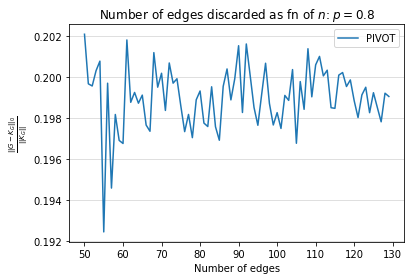

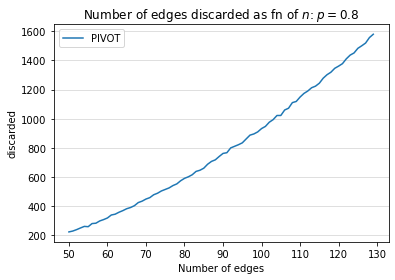

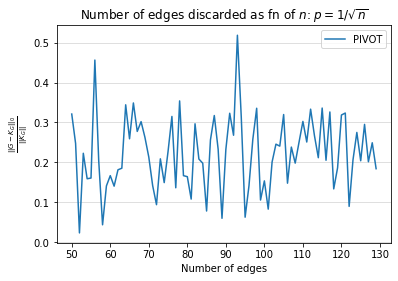

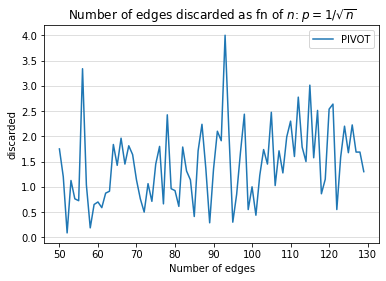

In [130]:
# plot all for number of discarded edges
for i in range(3):
    if i == 0:
        continue
    p = ALL_P[i]
    res = ALL_RES[i]
    title = "Number of edges discarded as fn of $n$: " + experiment_dict[i]
    savename = "GMR/"+"discarded_edges"+ "relative" + experiment_names[i] +".png"
#     savename=False
    plot_num_edges_removed(res,which_algs=ALL_GENERAL_GRAPHS & ALL_MR&ALL_BEFORE_11_ALGS, relative=True,
                           title = title, xlabel="Number of edges", ylabel="$\\frac{||G-K_G||_0}{||K_G||}$",
                            save = savename)
    
    savename = "GMR/"+"discarded_edges"+ "absolute" + experiment_names[i] +".png"
#     savename=False
    plot_num_edges_removed(res,which_algs=ALL_GENERAL_GRAPHS & ALL_MR&ALL_BEFORE_11_ALGS, relative=False,
                           title = title, xlabel="Number of edges", ylabel="discarded",
                            save = savename)

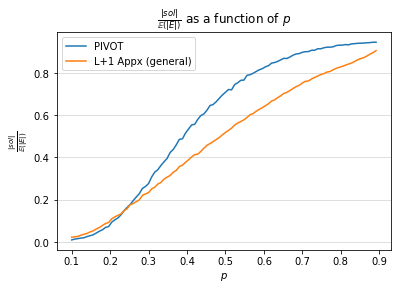

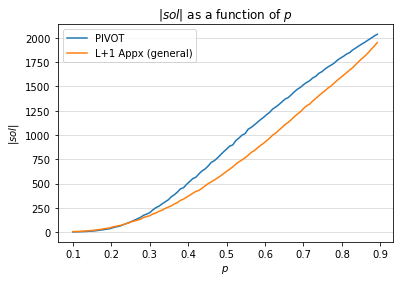

In [131]:
# Plot functions as function of $p$
title = "$\\frac{|sol|}{\mathbb{E}(|E|)}$ as a function of $p$"
savename = "GMR/pref_as_fn_of_p_relative.png"
# savename=False
algs_as_fn_p(pref_as_fn_p,which_algs=ALL_GENERAL_GRAPHS& ALL_MR& ALL_BEFORE_11_ALGS,
            title=title,
            DOMR=0,
             rel = ALL_RELATIVE[0],
            xlabel="$p$",
            ylabel="$\\frac{|sol|}{\mathbb{E}(|E|)}$",
            save=savename)

title = "$|sol|$ as a function of $p$"
savename = "GMR/pref_as_fn_of_p.png"
# savename=False
algs_as_fn_p(pref_as_fn_p,which_algs=ALL_GENERAL_GRAPHS& ALL_MR& ALL_BEFORE_11_ALGS,
            title=title,
            DOMR=0,
            xlabel="$p$",
            ylabel="$|sol|$",
             save=savename)

## Increase Only Metric Repair

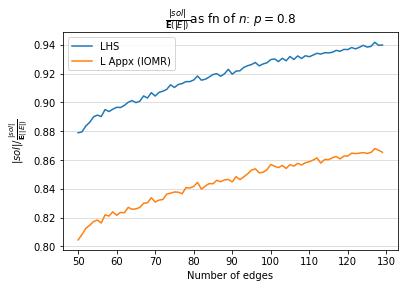

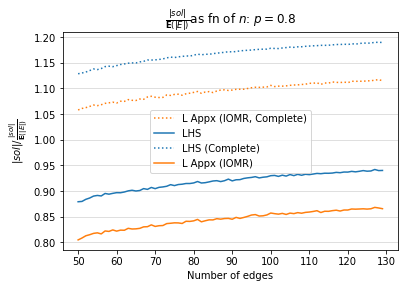

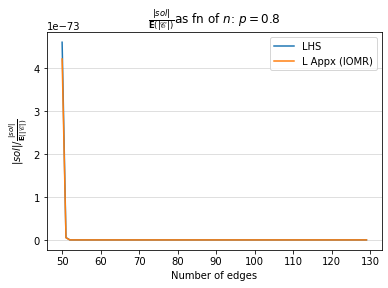

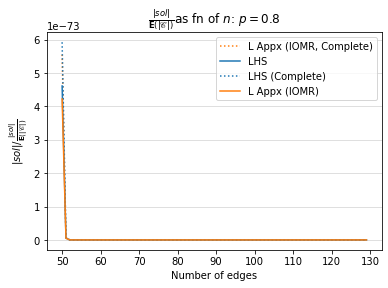

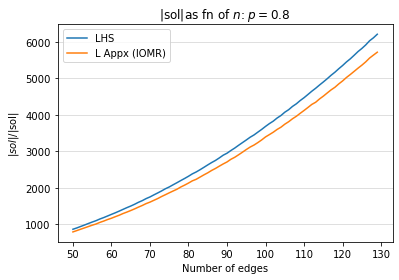

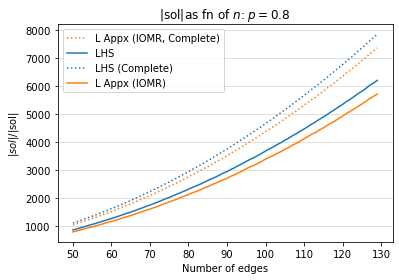

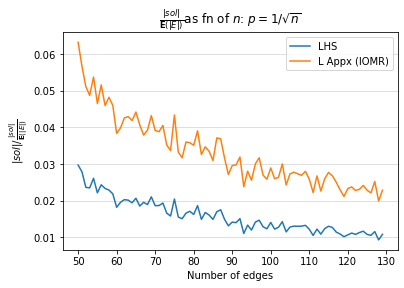

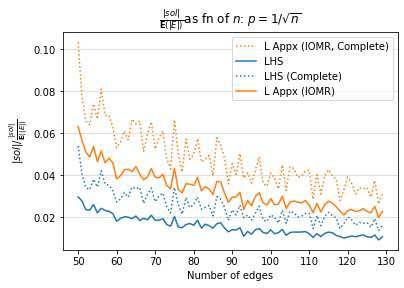

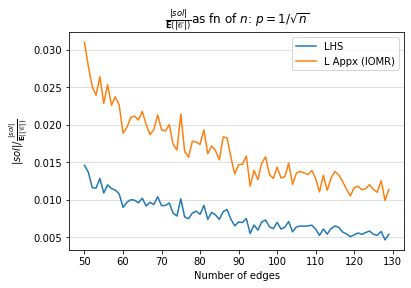

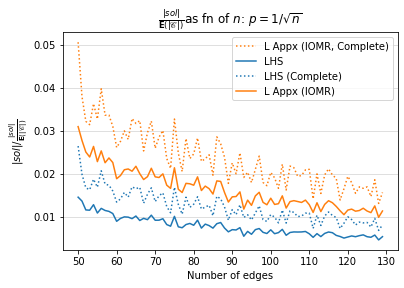

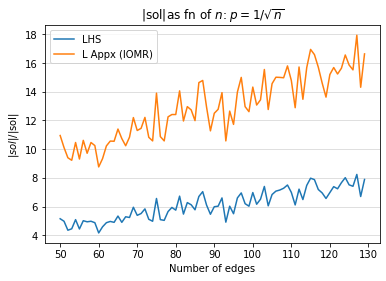

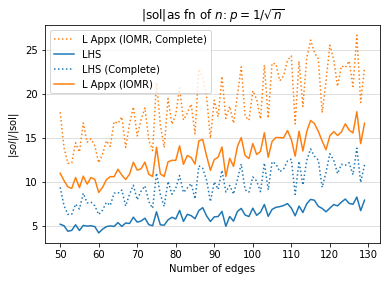

In [132]:
for i in range(3):
    if i == 0:
        continue
    p = ALL_P[i]
    res = ALL_RES[i]
    title = "$\\frac{|sol|}{\mathbb{E}(|E|)}$ as fn of $n$: " + experiment_dict[i]
    for j,rel in enumerate(ALL_RELATIVE):
        title = relative_dict[j] + "as fn of $n$: " + experiment_dict[i]
        savename = "IOMR/" + "sol_size" + relative_names[j] + experiment_names[i] + "IOMR_general" +".png"
#         savename=False
        plot_soln_over_rel(res,p,rel = rel, which_algs = (ALL_GENERAL_GRAPHS & ALL_IOMR&ALL_BEFORE_11_ALGS),
                               title=title,
                               xlabel="Number of edges",
                               ylabel="$|sol|/$" + relative_dict[j],
                               save=savename)
        
        title = relative_dict[j] + "as fn of $n$: " + experiment_dict[i]
        savename = "IOMR/" + "sol_size" + relative_names[j] + experiment_names[i] + "IOMR_all" +".png"
#         savename=False
        plot_soln_over_rel(res,p,rel = rel, which_algs =  ALL_IOMR&ALL_BEFORE_11_ALGS,
                               title=title,
                               xlabel="Number of edges",
                               ylabel="$|sol|/$" + relative_dict[j],
                               save=savename)
#         savename = "IOMR/" + "sol_size" + experiment_names[i] + "IOMR_complete" +".png"
#         plot_soln_over_rel(res,p,rel = rel, which_algs =  ALL_COMPLETE&ALL_IOMR,
#                                title=title,
#                                xlabel="Number of edges",
#                                ylabel="$||sol||/$" + relative_dict[j],
#                                save=savename)

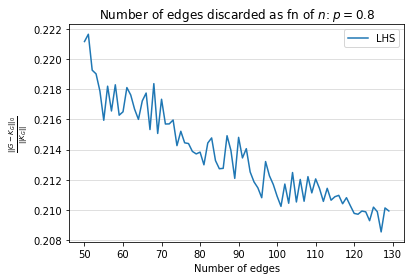

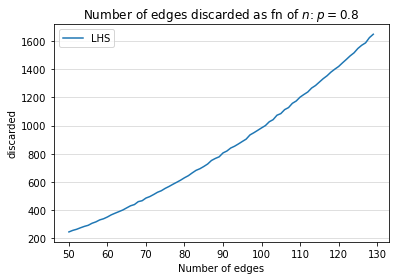

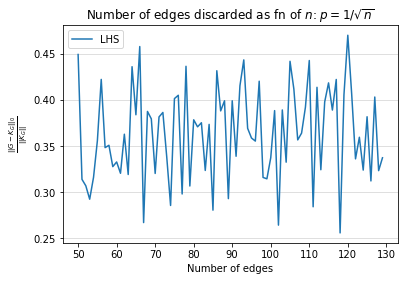

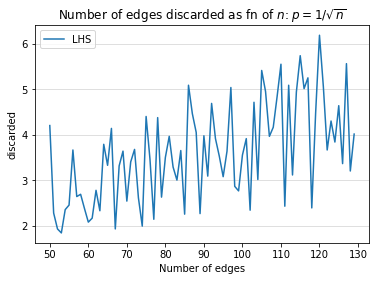

In [122]:
# plot all for number of discarded edges
for i in range(3):
    if i == 0:
        continue
    p = ALL_P[i]
    res = ALL_RES[i]
    title = "Number of edges discarded as fn of $n$: " + experiment_dict[i]
    savename = "IOMR/" + "discarded_edges" + "relative" + experiment_names[i] +".png"
    plot_num_edges_removed(res,which_algs=ALL_GENERAL_GRAPHS & ALL_IOMR&ALL_BEFORE_11_ALGS, relative=True,
                           title = title, xlabel="Number of edges", ylabel="$\\frac{||G-K_G||_0}{||K_G||}$",
                          save = savename)
    savename = "IOMR/" + "discarded_edges" + "absolute" + experiment_names[i] +".png"
    plot_num_edges_removed(res,which_algs=ALL_GENERAL_GRAPHS & ALL_IOMR&ALL_BEFORE_11_ALGS, relative=False,
                           title = title, xlabel="Number of edges", ylabel="discarded",
                          save = savename)

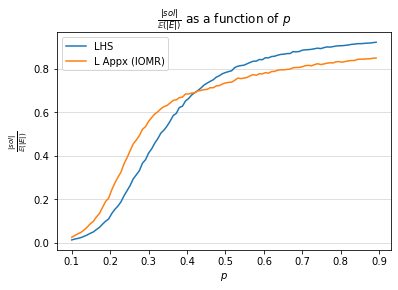

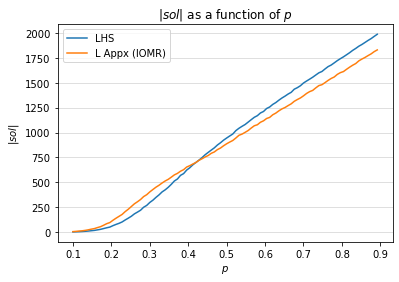

In [123]:
# Plot functions as function of $p$
title = "$\\frac{|sol|}{\mathbb{E}(|E|)}$ as a function of $p$"
savename = "IOMR/pref_as_fn_of_p_relative.png"
algs_as_fn_p(pref_as_fn_p,which_algs=ALL_GENERAL_GRAPHS& ALL_IOMR& ALL_BEFORE_11_ALGS,
            title=title,
            DOMR=0,
             rel = ALL_RELATIVE[0],
            xlabel="$p$",
            ylabel="$\\frac{|sol|}{\mathbb{E}(|E|)}$",
            save=savename)

title = "$|sol|$ as a function of $p$"
savename = "IOMR/pref_as_fn_of_p.png"
algs_as_fn_p(pref_as_fn_p,which_algs=ALL_GENERAL_GRAPHS& ALL_IOMR& ALL_BEFORE_11_ALGS,
            title=title,
            DOMR=0,
            xlabel="$p$",
            ylabel="$|sol|$",
             save=savename)